In [82]:
import numpy as np
import matplotlib.pyplot as plt
from funciones_t5 import euler_cromer, loc_max
from matplotlib.animation import FuncAnimation


# Constantes
Ms = 4*np.pi**2
M_sol = 2e30
Mj = 1.9e27

q = Mj/M_sol
GMj = q*Ms

# Jupiter
Rj = 5.2
Tj = 11.86
omegaj = 2*np.pi/Tj

# Halley
r0 = 0.59
vy0 = 11.47270
Periodo = 75.979
T = 10*Periodo

dt = 0.0005

In [83]:

# Sistema Sol
def sistema(t,estado):

    x,vx,y,vy = estado
    r = np.sqrt(x**2+y**2)

    ax = -Ms*x/r**3
    ay = -Ms*y/r**3

    return np.array([vx,ax,vy,ay])


# Sistema Sol + Jupiter
def sistema_j(t,estado):

    x,vx,y,vy = estado

    r = np.sqrt(x**2+y**2)

    # orbita circular de Jupiter
    xj = Rj*np.cos(omegaj*t + 5*np.pi/4)
    yj = Rj*np.sin(omegaj*t)

    dx = x-xj
    dy = y-yj
    rj = np.sqrt(dx**2+dy**2)

    ax = -Ms*x/r**3 - GMj*dx/rj**3
    ay = -Ms*y/r**3 - GMj*dy/rj**3

    return np.array([vx,ax,vy,ay])


# condiciones iniciales
estado0 = np.array([r0,0,0,vy0])

In [84]:
# integración
t, vars = euler_cromer(sistema,0,T,estado0,dt)
tpr, varspr = euler_cromer(sistema_j,0,T,estado0,dt)


# Trayectoria de jupiter
thj = np.linspace(0,2*np.pi, 100)
xxjr = Rj*np.cos(thj)
yyjr = Rj*np.sin(thj)


# soluciones
x = vars[:,0]
y = vars[:,2]

xpr = varspr[:,0]
ypr = varspr[:,2]

C:\Users\nol4n\AppData\Local\Temp\ipykernel_8532\1762917656.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  eje.legend()


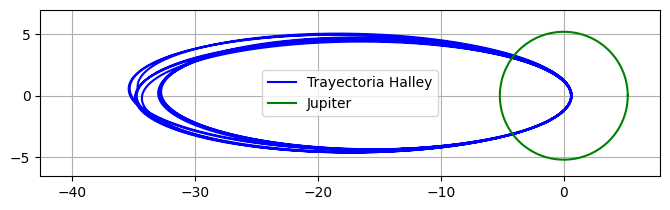

In [85]:

figura, eje = plt.subplots(figsize  = (8,6))

xl = 0.2*np.abs(np.max(xpr) - np.min(xpr))
yl = 0.2*np.abs(np.max(ypr) - np.min(ypr))

eje.set_xlim(np.min(xpr)-xl , np.max(xpr)+xl)
eje.set_ylim(np.min(ypr)-yl , np.max(ypr)+yl)
eje.grid()
eje.set_aspect("equal")
eje.legend()

eje.plot(xpr,ypr,color = 'b', label = 'Trayectoria Halley')
eje.plot(xxjr,yyjr, color = 'green', label = 'Jupiter')


eje.legend()
plt.show()

In [91]:
r = np.sqrt(x**2 + y**2)
iM, _ = loc_max(r)
# im, _ = loc_min(r)

t = np.array(t)
tpr = np.array(tpr)

iM.astype(np.int16)
ttM = t[iM]/Periodo
# ttm = t[im]/Periodo

theta = np.arctan(y[iM]/x[iM])

print('r', r[iM])



# Con precesion
rpr = np.sqrt(xpr**2 + ypr**2)
iMpr, _ = loc_max(rpr)
# impr, _ = loc_min(rpr)

ttpM = tpr[iMpr]/Periodo
print('r', rpr[iMpr])

r [35.28791517 35.28791516 35.28791516 35.28791517 35.28791517 35.28791516
 35.28791516 35.28791517 35.28791516 35.28791516]
r [34.30665752 34.85317591 34.81913496 34.72359186 32.98264585 32.84263934
 32.74709568 32.85437335 35.38517884 35.29929578 34.66590299]
